<a href="https://colab.research.google.com/github/zackdihel/DA-project-1/blob/main/notebooks/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AI Extension**

For this project relating to Card & Krueger's 1994 paper on fast-food minimum wage effects on employment, I've used **Claude** as an AI copilot to expand the original research and explore a question related to the original findings. Essentially this question is whether the employment trends of Pennsylvania and New Jersey were appropriate comparison environments, or if the employment trends of both states were following different paths prior to the legislation which increased NJ's minimum wage.

To do do this, I've opted to use an event study in order to analyze each state's data in multiple periods leading up to the minimum wage change, and multiple periods after. Using BLS QCEW data to build a broader understanding of what each state's employment picture was looking like, and how much or how little the minimum wage increase may have altered that picture.

I will notate the prompts I used to assist in developing the code and visualizations necessary for this extension.

**Initial AI prompt**: Let's do an event study for Card & Krueger (1992), covering 2 years before the minimum wage change and 3 years after the change.

**AI Prompt**: How would I pull BLS data for this extension?

In [29]:
# BLS API key
# e0c8d45def5b4787a1936c8c087a0467

In [30]:
import requests
import pandas as pd
import json

def get_bls_data(series_ids, start_year, end_year, api_key):
    url = 'https://api.bls.gov/publicAPI/v2/timeseries/data/'

    headers = {'Content-type': 'application/json'}
    data = json.dumps({
        'seriesid': series_ids,
        'startyear': str(start_year),
        'endyear': str(end_year),
        'registrationkey': api_key
    })

    response = requests.post(url, data=data, headers=headers)
    return response.json()

# Series IDs for NJ and PA fast food employment (FIRST ATTEMPT)
# series_ids = [
#     'SMU34000007072200001',  # NJ fast food employment
#     'SMU42000007072200001'   # PA fast food employment
# ]

#SECOND ATTEMPT - adding more states
series_ids = [
    'SMU34000007072259001',  # NJ
    'SMU42000007072259001',  # PA
]

api_key = 'e0c8d45def5b4787a1936c8c087a0467'

data = get_bls_data(series_ids, 1990, 1994, api_key)

In [31]:
records = []
for series in data['Results']['series']:
    state = 'NJ' if '34' in series['seriesID'] else 'PA'
    for obs in series['data']:
        # Only keep quarterly months (March, June, September, December)
        # to approximate quarters
        if obs['period'] in ['M03', 'M06', 'M09', 'M12']:
            records.append({
                'state': state,
                'year': int(obs['year']),
                'month': obs['period'],
                'periodName': obs['periodName'],
                'employment': float(obs['value'])
            })

df_bls = pd.DataFrame(records)

# Map months to quarters
quarter_map = {'M03': 1, 'M06': 2, 'M09': 3, 'M12': 4}
df_bls['quarter_num'] = df_bls['month'].map(quarter_map)

# Create single time variable (quarters since Q1 1990)
df_bls['time'] = (df_bls['year'] - 1990) * 4 + df_bls['quarter_num']

# Treatment is Q1 1992 = quarter 9
df_bls['time_to_treat'] = df_bls['time'] - 9

# Treatment indicator
df_bls['Treat'] = (df_bls['state'] == 'NJ').astype(int)

# Sort
df_bls = df_bls.sort_values(['state', 'year', 'quarter_num']).reset_index(drop=True)

print(df_bls.head(10))
print(f"\nTime periods available: {sorted(df_bls['time_to_treat'].unique())}")
print(f"\nStates: {df_bls['state'].unique()}")

  state  year month periodName  employment  quarter_num  time  time_to_treat  \
0    NJ  1990   M03      March        52.5            1     1             -8   
1    NJ  1990   M06       June        59.8            2     2             -7   
2    NJ  1990   M09  September        57.0            3     3             -6   
3    NJ  1990   M12   December        52.3            4     4             -5   
4    NJ  1991   M03      March        51.8            1     5             -4   
5    NJ  1991   M06       June        56.0            2     6             -3   
6    NJ  1991   M09  September        57.5            3     7             -2   
7    NJ  1991   M12   December        53.8            4     8             -1   
8    NJ  1992   M03      March        51.6            1     9              0   
9    NJ  1992   M06       June        57.5            2    10              1   

   Treat  
0      1  
1      1  
2      1  
3      1  
4      1  
5      1  
6      1  
7      1  
8      1  
9      1 

Previous code pulls data from BLS quarterly censuses for 8 pre-treatment periods and 12 post-treatment periods

**Event Study**

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1971: RuntimeWarning: invalid value encountered in multiply
  scale[:, None] * self.model.pinv_wexog.T)


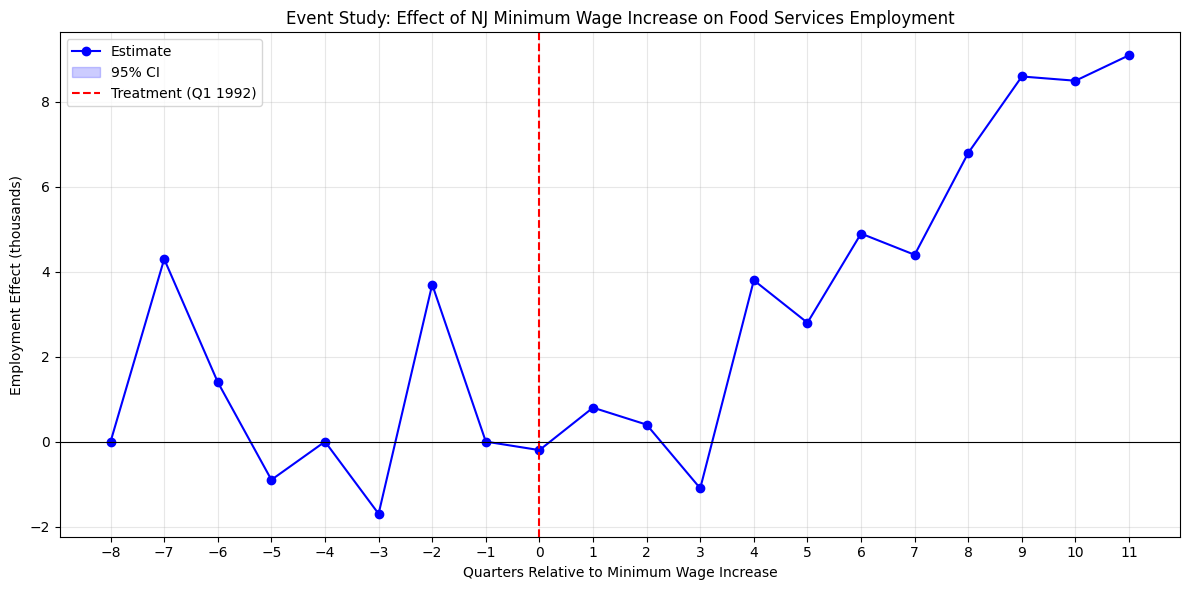


Pre-treatment coefficients (should be close to 0):
Period  -8: coef =  0.000, 95% CI = [0.000, 0.000] 
Period  -7: coef =  4.300, 95% CI = [nan, nan] 
Period  -6: coef =  1.400, 95% CI = [nan, nan] 
Period  -5: coef = -0.900, 95% CI = [nan, nan] 
Period  -4: coef = -0.000, 95% CI = [nan, nan] 
Period  -3: coef = -1.700, 95% CI = [nan, nan] 
Period  -2: coef =  3.700, 95% CI = [nan, nan] 


In [32]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np

# Drop time_to_treat = -1 as the reference period
df_event = df_bls[df_bls['time_to_treat'] != -1].copy()

# Run event study regression with state and time fixed effects
model = smf.ols(
    'employment ~ C(time_to_treat) * Treat + C(time_to_treat) + C(state)',
    data=df_event
).fit(cov_type='HC1')

# Extract interaction coefficients (Treat effect at each time period)
coef_names = [col for col in model.params.index if 'Treat' in col and 'time_to_treat' in col]
coefs = model.params[coef_names]
errors = model.bse[coef_names] * 1.96

# Extract time periods from coefficient names
periods = sorted(df_event['time_to_treat'].unique())
periods = [p for p in periods if p != -1]

# Add back reference period (0 by definition)
all_periods = sorted(df_bls['time_to_treat'].unique())
coef_values = []
error_values = []

for p in all_periods:
    if p == -1:
        coef_values.append(0)
        error_values.append(0)
    else:
        matching = [c for c in coef_names if f'[T.{p}]' in c]
        if matching:
            coef_values.append(coefs[matching[0]])
            error_values.append(errors[matching[0]])
        else:
            coef_values.append(0)
            error_values.append(0)

coef_values = np.array(coef_values)
error_values = np.array(error_values)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(all_periods, coef_values, marker='o', color='blue', label='Estimate')
plt.fill_between(all_periods,
                 coef_values - error_values,
                 coef_values + error_values,
                 alpha=0.2, color='blue', label='95% CI')
plt.axvline(x=0, color='red', linestyle='--', label='Treatment (Q1 1992)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Quarters Relative to Minimum Wage Increase')
plt.ylabel('Employment Effect (thousands)')
plt.title('Event Study: Effect of NJ Minimum Wage Increase on Food Services Employment')
plt.legend()
plt.xticks(all_periods)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print pre-trend test
print("\nPre-treatment coefficients (should be close to 0):")
for p, c, e in zip(all_periods, coef_values, error_values):
    if p < -1:
        sig = '***' if abs(c) > e else ''
        print(f"Period {p:3d}: coef = {c:6.3f}, 95% CI = [{c-e:.3f}, {c+e:.3f}] {sig}")

Pre-treat coefs are not close to zero which would be what indicated a parallel starting point for each state. In order to try and address this we could add additional nearby states to the data series we're using.

# Counterpoint

Adding additional states defeates the purpose of the naturally occurring A/B test we had with PA and NJ. We can't control for the additional states' minimum wages.

**AI prompt**: Return to just New Jersey and Pennsylvania and construct a parallel trends visualization.

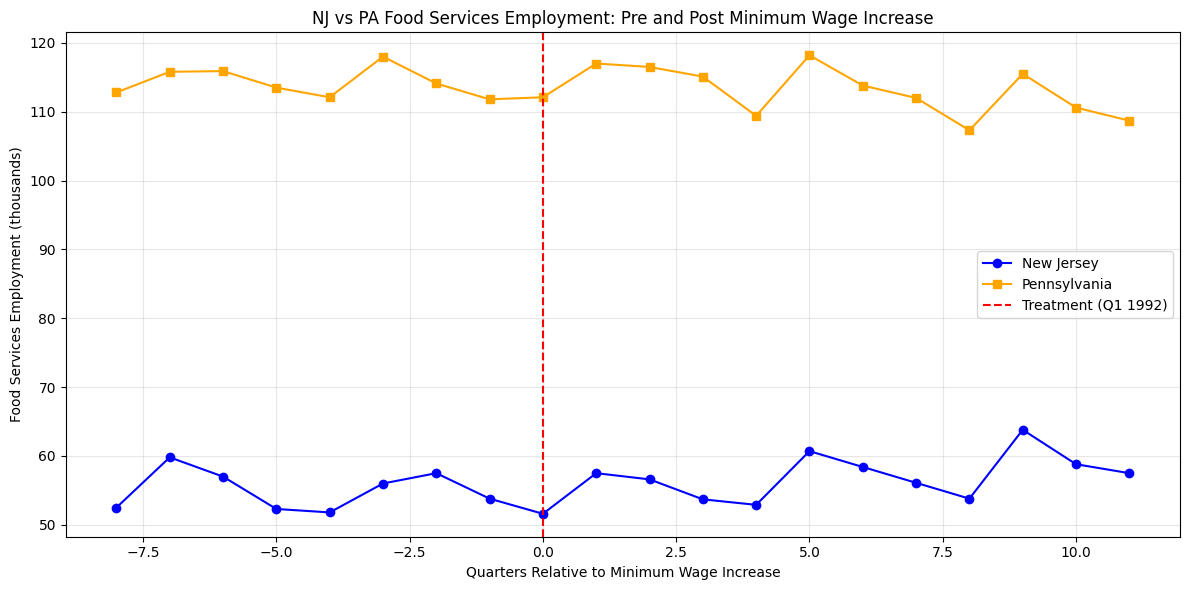

In [33]:
# Simple visual parallel trends check with just NJ and PA
nj = df_bls[df_bls['state'] == 'NJ']
pa = df_bls[df_bls['state'] == 'PA']

plt.figure(figsize=(12, 6))
plt.plot(nj['time_to_treat'], nj['employment'],
         marker='o', color='blue', label='New Jersey')
plt.plot(pa['time_to_treat'], pa['employment'],
         marker='s', color='orange', label='Pennsylvania')
plt.axvline(x=0, color='red', linestyle='--', label='Treatment (Q1 1992)')
plt.xlabel('Quarters Relative to Minimum Wage Increase')
plt.ylabel('Food Services Employment (thousands)')
plt.title('NJ vs PA Food Services Employment: Pre and Post Minimum Wage Increase')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Visually this would seem to indicate that PA and NJ were on comparable trends

# **Further extension**

The raw numbers in our trend have a large gap just due to the population difference betwen PA and NJ. Let's try and use logs and see what we get.

**AI Prompt:** Can we log transform the data for our second visualization and see that trend

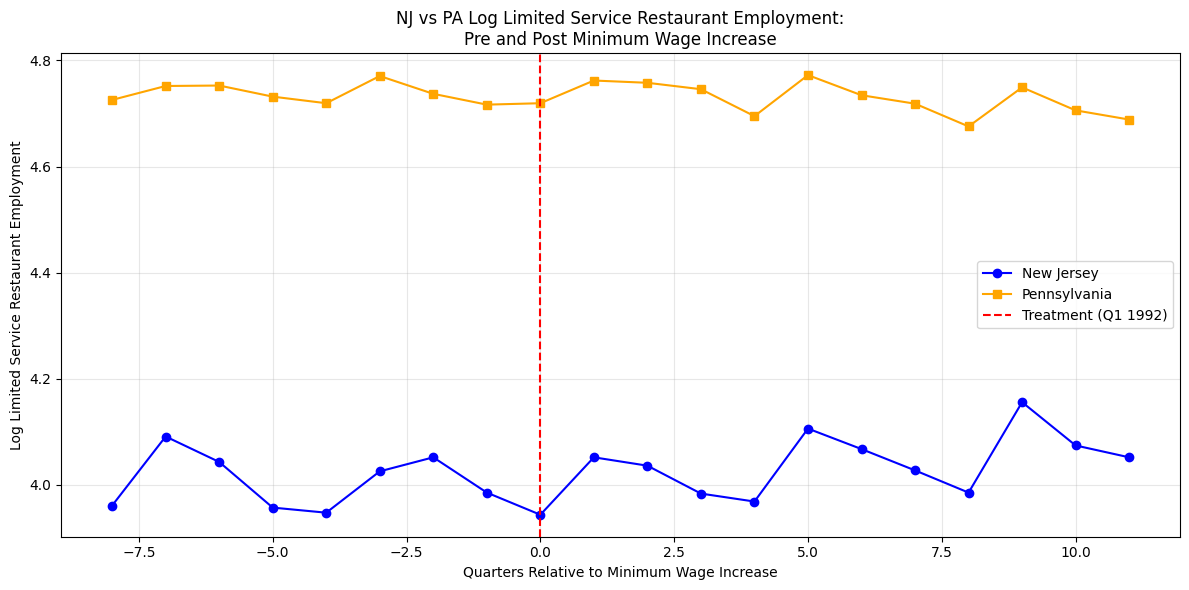

In [38]:
import numpy as np

nj = df_bls[df_bls['state'] == 'NJ'].copy()
pa = df_bls[df_bls['state'] == 'PA'].copy()

# Log transform employment
nj['log_employment'] = np.log(nj['employment'])
pa['log_employment'] = np.log(pa['employment'])

plt.figure(figsize=(12, 6))
plt.plot(nj['time_to_treat'], nj['log_employment'],
         marker='o', color='blue', label='New Jersey')
plt.plot(pa['time_to_treat'], pa['log_employment'],
         marker='s', color='orange', label='Pennsylvania')
plt.axvline(x=0, color='red', linestyle='--', label='Treatment (Q1 1992)')
plt.xlabel('Quarters Relative to Minimum Wage Increase')
plt.ylabel('Log Limited Service Restaurant Employment')
plt.title('NJ vs PA Log Limited Service Restaurant Employment:\nPre and Post Minimum Wage Increase')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**AI Prompt:** what would a smoothed trend line look like?

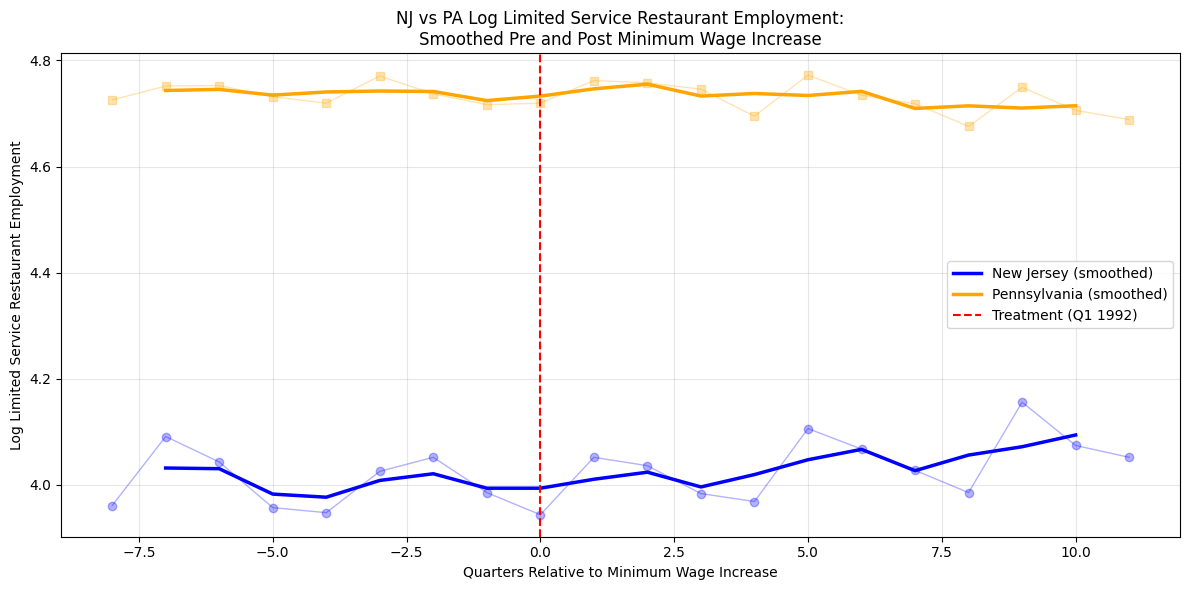

In [39]:
import numpy as np
import matplotlib.pyplot as plt

nj = df_bls[df_bls['state'] == 'NJ'].copy()
pa = df_bls[df_bls['state'] == 'PA'].copy()

# Log transform
nj['log_employment'] = np.log(nj['employment'])
pa['log_employment'] = np.log(pa['employment'])

# Smoothed trend using rolling average (window of 3 quarters)
nj['smoothed'] = nj['log_employment'].rolling(window=3, center=True).mean()
pa['smoothed'] = pa['log_employment'].rolling(window=3, center=True).mean()

plt.figure(figsize=(12, 6))

# Raw data (faded)
plt.plot(nj['time_to_treat'], nj['log_employment'],
         marker='o', color='blue', alpha=0.3, linewidth=1)
plt.plot(pa['time_to_treat'], pa['log_employment'],
         marker='s', color='orange', alpha=0.3, linewidth=1)

# Smoothed trend (bold)
plt.plot(nj['time_to_treat'], nj['smoothed'],
         color='blue', linewidth=2.5, label='New Jersey (smoothed)')
plt.plot(pa['time_to_treat'], pa['smoothed'],
         color='orange', linewidth=2.5, label='Pennsylvania (smoothed)')

plt.axvline(x=0, color='red', linestyle='--', label='Treatment (Q1 1992)')
plt.xlabel('Quarters Relative to Minimum Wage Increase')
plt.ylabel('Log Limited Service Restaurant Employment')
plt.title('NJ vs PA Log Limited Service Restaurant Employment:\nSmoothed Pre and Post Minimum Wage Increase')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Regression**

**AI Prompt:** Now that the visualization is finished, how would I run a regression with this data to test the hypothesis that PA and NJ had parallel trends prior to the minimum wage change, and diverging ones after?

In [40]:
# Pre-treatment data only
df_pre = df_bls[df_bls['time_to_treat'] < 0].copy()
df_pre['log_employment'] = np.log(df_pre['employment'])

# Interact time trend with treatment to test if NJ and PA
# were trending differently before the minimum wage increase
model_pre = smf.ols(
    'log_employment ~ time_to_treat * Treat + C(quarter_num)',
    data=df_pre
).fit()

print("--- Pre-Trend Test ---")
print(model_pre.summary().tables[1])
print("\nKey result: 'time_to_treat:Treat' coefficient")
print("If close to 0 and insignificant -> parallel trends holds")

--- Pre-Trend Test ---
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.6921      0.029    163.040      0.000       4.627       4.757
C(quarter_num)[T.2]     0.0733      0.020      3.748      0.005       0.029       0.118
C(quarter_num)[T.3]     0.0616      0.020      3.016      0.015       0.015       0.108
C(quarter_num)[T.4]     0.0150      0.022      0.690      0.508      -0.034       0.064
time_to_treat          -0.0019      0.005     -0.426      0.680      -0.012       0.008
Treat                  -0.7301      0.030    -24.323      0.000      -0.798      -0.662
time_to_treat:Treat  8.612e-05      0.006      0.014      0.989      -0.013       0.014

Key result: 'time_to_treat:Treat' coefficient
If close to 0 and insignificant -> parallel trends holds


In [41]:
# Full dataset
df_bls['log_employment'] = np.log(df_bls['employment'])
df_bls['Post'] = (df_bls['time_to_treat'] >= 0).astype(int)

# This tests three things:
# - Pre-treatment trend difference (time_to_treat:Treat)
# - Post-treatment level shift (Treat:Post)
# - Post-treatment trend difference (time_to_treat:Treat:Post)
model_full = smf.ols(
    'log_employment ~ time_to_treat * Treat * Post + C(quarter_num)',
    data=df_bls
).fit()

print("--- Full Model ---")
print(model_full.summary().tables[1])

--- Full Model ---
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    4.6829      0.020    234.516      0.000       4.642       4.724
C(quarter_num)[T.2]          0.0896      0.010      8.862      0.000       0.069       0.110
C(quarter_num)[T.3]          0.0621      0.010      5.978      0.000       0.041       0.083
C(quarter_num)[T.4]          0.0267      0.011      2.467      0.020       0.005       0.049
time_to_treat               -0.0024      0.004     -0.670      0.508      -0.010       0.005
Treat                       -0.7301      0.025    -29.572      0.000      -0.781      -0.680
time_to_treat:Treat       8.612e-05      0.005      0.018      0.986      -0.010       0.010
Post                         0.0261      0.022      1.187      0.245      -0.019       0.071
time_to_treat:Post          -0.0024      0.004     

In [42]:
# Summarize the key coefficients
print("\nKey coefficients to interpret:")
print(f"Pre-trend (time_to_treat:Treat):        {model_full.params['time_to_treat:Treat']:.4f}")
print(f"Post level shift (Treat:Post):           {model_full.params['Treat:Post']:.4f}")
print(f"Post trend difference (time*Treat*Post): {model_full.params['time_to_treat:Treat:Post']:.4f}")


Key coefficients to interpret:
Pre-trend (time_to_treat:Treat):        0.0001
Post level shift (Treat:Post):           -0.0287
Post trend difference (time*Treat*Post): 0.0125
